In [1]:
import matplotlib.pyplot as plt
import cv2, os

arq_img = "graos.png"

In [2]:
def mostrar_imagens_lado_a_lado(img1, img2, titulo1="Original", titulo2="Modificada"):
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img1, cmap='gray')
    plt.title(titulo1)
    plt.subplot(1, 2, 2)
    plt.imshow(img2, cmap='gray')
    plt.title(titulo2)
    plt.tight_layout()
    plt.show()

#### 1) Ler uma imagem de entrada

In [3]:
# Carrega a imagem colorida em BGR
img = cv2.imread(arq_img)

#### 2) Aplicar conversão para escala de cinza;

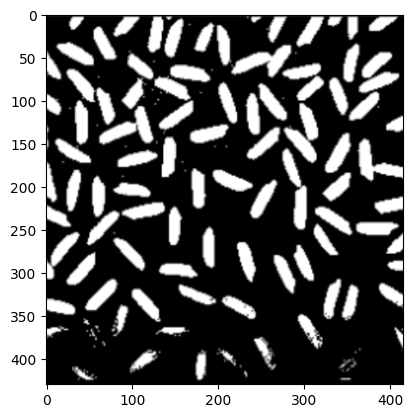

In [4]:
# Converte para escala de cinza
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Exibe a imagem em escala de cinza
plt.imshow(gray, cmap="gray")
plt.show()

#### 3) Realizar suavização com filtro Gaussiano;

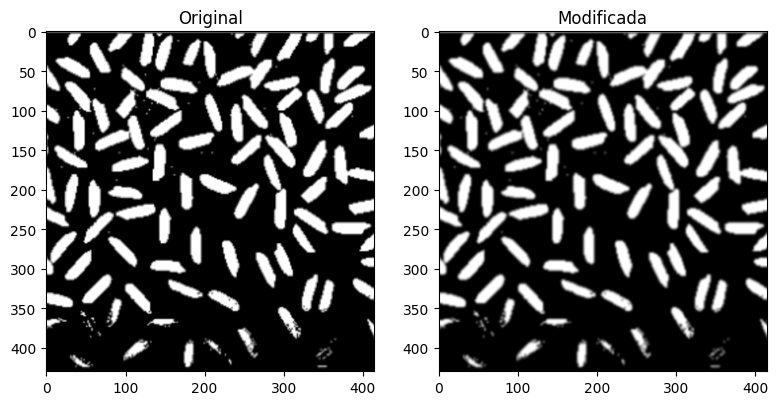

In [5]:
# Aplica o filtro gaussiano
blurred = cv2.GaussianBlur(gray, (5,5), 0)

mostrar_imagens_lado_a_lado(gray, blurred) # Exibe a imagem original e a modificada lado a lado

#### 4) Binarizar a imagem (thresholding);

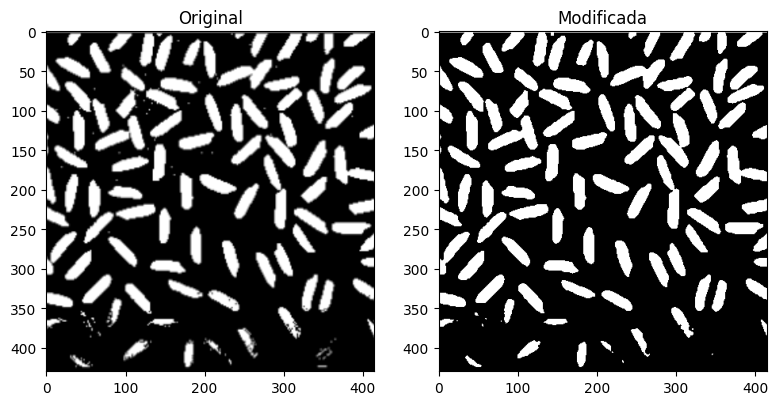

In [6]:
# Binarização automática utilizando Otsu (escolhe automaticamente o valor do threshold)
limiar, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

mostrar_imagens_lado_a_lado(gray, binary) # Exibe a imagem original e a modificada lado a lado

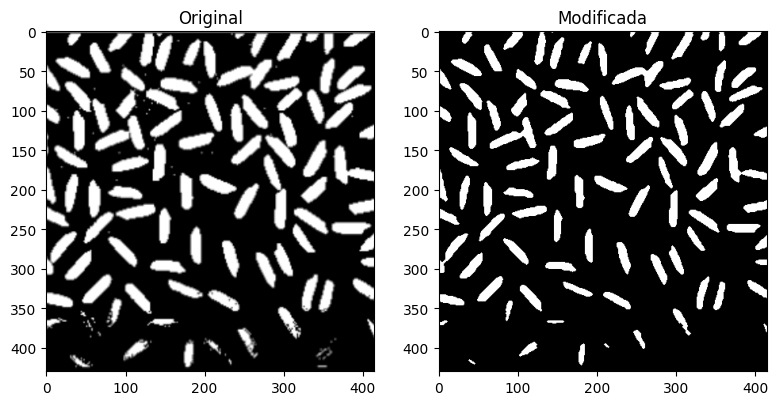

In [7]:
# Cria o elemento estruturante
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3, 3))

# Aplica a erosão para separar os elementos
imagem_erodida = cv2.erode(binary, kernel, iterations=2)

# Aplica a abertura realiza uma erosão seguida de uma dilatação, ajudando a remover pequenos pontos e ruídos isolados.
img_abertura = cv2.morphologyEx(imagem_erodida, cv2.MORPH_OPEN, kernel, iterations=1)

mostrar_imagens_lado_a_lado(gray, img_abertura) # Exibe a imagem original e a modificada lado a lado

#### 5) Utilizar contornos para identificar e contar os objetos;

In [8]:
MIN_AREA = 30

# Localiza apenas os contornos externos dos objetos presentes na imagem após a remoção dos ruídos.
contours, _ = cv2.findContours(img_abertura, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Percorre todos os contornos encontrados e mantém somente aqueles cuja área seja maior ou igual ao valor mínimo definido.
# Isso evita que pequenos ruídos sejam contabilizados como objetos.
valid_contours = []
for c in contours:
    area = cv2.contourArea(c)
    if area >= MIN_AREA:
        valid_contours.append(c)

object_count = len(valid_contours)
print(f"Número de objetos encontrados: {object_count}")

Número de objetos encontrados: 87


#### 6) Exibir a imagem com a contagem anotada.

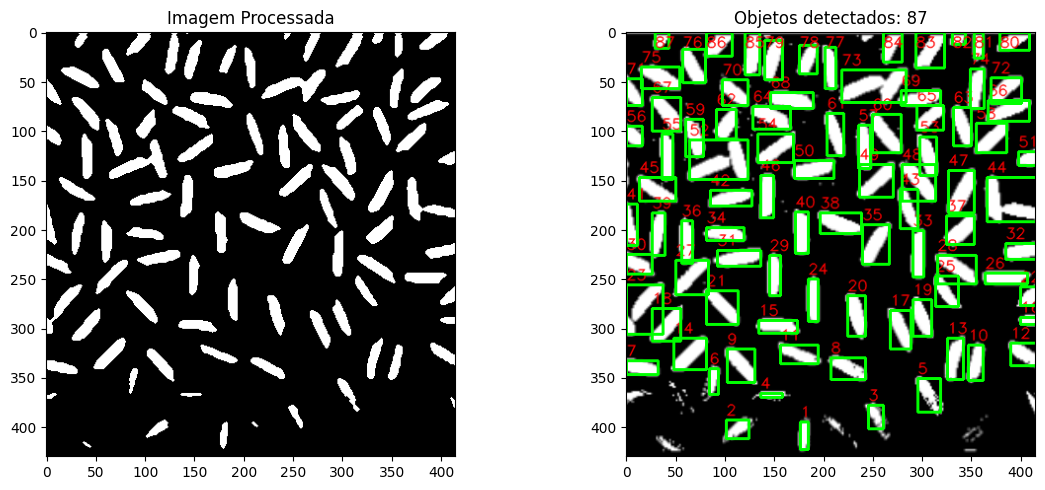

In [9]:
# Cria uma cópia para desenhar os resultados
result = img.copy()

# Desenha e numera os objetos encontrados
for index, contour in enumerate(valid_contours, start=1):
    x, y, w, h = cv2.boundingRect(contour)
    cv2.rectangle(result, (x,y), (x+w,y+h), (0,255,0), 2)
    cv2.putText(result, str(index), (x, max(y-5,15)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1, cv2.LINE_AA)

# OpenCV usa BGR; matplotlib usa RGB
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# Exibe as imagens dentro do Jupyter
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_abertura, cmap="gray")
plt.title("Imagem Processada")
plt.subplot(1, 2, 2)
plt.imshow(result_rgb)
plt.title(f"Objetos detectados: {object_count}")
plt.tight_layout()
plt.show()  